# 🫀 ECG ResNet1D — **v1 LIGERO** (CPU · modelo independiente)
## TFM · Módulo de Electrocardiograma · Universidad de Salamanca

---

## 🎯 Qué es esta versión (la más ligera de las 3)
El ECG aporta señal **indirecta** sobre los hallazgos radiográficos (techo ~0.63–0.64 AUC). Esta versión es la **línea
base rápida**: una **ResNet1D pequeña** entrenada desde cero sobre la señal de 12 derivaciones, a baja resolución.

| Las 3 versiones | Arquitectura | Señal | Coste CPU |
|---|---|---|---|
| **v1 (esta, ligera)** | ResNet1D base **32**, **1 bloque/etapa** | **1000** | ~20–40 min |
| v2 (óptima) | base 48, 2 bloques/etapa, Optuna, K-fold ensemble | 1250 | ~3–4 h |
| v3 (pesada) | base 64, 2 bloques/etapa, K=5, aug rica | 2500 | muchas horas (<24 h) |

## 🛡️ Bases del proyecto (intactas)
Masking de NaN/−1 · **negativos derivados por exclusividad de *No Finding*** · `pos_weight` dinámico · z-score por
derivación · **calibración isotónica** · **OOF sin fuga** para el stacking. Salidas ricas (confusión, ROC/PR, AUC).


In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try: import torch  # noqa
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","--index-url","https://download.pytorch.org/whl/cpu","-q"],check=True)
for p in ["scikit-learn","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q"],check=False)
print("Dependencias listas.")

Dependencias listas.


In [2]:
# CELDA 2 · IMPORTS, RUTAS Y CONSTANTES
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4); DEVICE=torch.device("cpu")

BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV=BASE/"data_csv"/"clean"; NPY=BASE/"data_npy"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV/"train_clean.csv",CSV/"val_clean.csv",CSV/"test_clean.csv"
ECG_NPY={"train":NPY/"train"/"ecg_train.npy","val":NPY/"val"/"ecg_val.npy","test":NPY/"test"/"ecg_test.npy"}
HADM_NPY={"train":NPY/"train"/"hadm_id_train.npy","val":NPY/"val"/"hadm_id_val.npy","test":NPY/"test"/"hadm_id_test.npy"}
OUTPUT_DIR=Path("outputs_ecg_resnet1d_v1"); OUTPUT_DIR.mkdir(exist_ok=True)
PREP=OUTPUT_DIR/"prep"; PREP.mkdir(exist_ok=True); FIG=OUTPUT_DIR/"figuras"; FIG.mkdir(exist_ok=True)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY=[l for l in LABELS if l!=NO_FINDING]; CORE=["Cardiomegaly","Edema","Pleural Effusion"]
N_LEADS,ECG_RAW_LEN=12,5000
ECG_LEN=1000          # v1: baja resolución (rápido)
BATCH=64; BASE_WIDTH=32; BLOCKS=1          # v1: red pequeña
K_FOLDS,EPOCHS,PATIENCE=3,15,4
print("Salidas en", OUTPUT_DIR, "· ECG_LEN", ECG_LEN, "· base", BASE_WIDTH)

c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Salidas en outputs_ecg_resnet1d_v1 · ECG_LEN 1000 · base 32


In [3]:
# CELDA 3 · CARGA Y ALINEACIÓN CSV <-> señal ECG (join por hadm_id)
def load_split(csv,ecg,hadm,name):
    df=pd.read_csv(csv,sep=";"); h=np.load(hadm,allow_pickle=True); h2i={int(x):i for i,x in enumerate(h)}
    df["_npy_idx"]=df["hadm_id"].map(lambda z:h2i.get(int(z),-1)); n0=len(df)
    df=df[df["_npy_idx"]>=0].reset_index(drop=True); a=np.load(ecg,mmap_mode="r")
    print(f"{name:5s}: CSV={n0:,} con ECG={len(df):,} · señal {a.shape}"); return df,a
df_train,ecg_train=load_split(TRAIN_CSV,ECG_NPY["train"],HADM_NPY["train"],"train")
df_val,ecg_val=load_split(VAL_CSV,ECG_NPY["val"],HADM_NPY["val"],"val")
df_test,ecg_test=load_split(TEST_CSV,ECG_NPY["test"],HADM_NPY["test"],"test")

train: CSV=10,000 con ECG=10,000 · señal (10000, 1, 5000, 12)
val  : CSV=750 con ECG=750 · señal (750, 1, 5000, 12)
test : CSV=464 con ECG=464 · señal (4640, 1, 5000, 12)


In [4]:
# CELDA 4 · OBJETIVOS (masking de NaN/−1 + negativos derivados por exclusividad de 'No Finding')
def build_targets(df, uncertainty_policy="zeros", derive=True, verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; ndp=ndn=0
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; ndp+=int(f.sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; ndn=int(fn.sum())
    if verbose: print(f"   negativos derivados -> patologías={ndp:,} · No Finding={ndn:,}")
    return labels,mask
y_train,m_train=build_targets(df_train,verbose=True)
y_val,m_val=build_targets(df_val); y_test,m_test=build_targets(df_test)

   negativos derivados -> patologías=6,091 · No Finding=7,691


In [5]:
# CELDA 5 · PREPROCESADO de la señal (downsample a 1000 + z-score por derivación), con caché
def preprocess(df, ecg, name):
    cache=PREP/f"ecg_{name}_{ECG_LEN}.npy"
    if cache.exists():
        X=np.load(cache)
        if len(X)==len(df): print(f"   {name}: caché {X.shape}"); return X
    idx=df["_npy_idx"].to_numpy(); factor=ECG_RAW_LEN//ECG_LEN
    X=np.empty((len(idx),N_LEADS,ECG_LEN),np.float32)
    for k in tqdm(range(len(idx)),desc=f"prep {name}",leave=False):
        a=np.asarray(ecg[int(idx[k])],np.float32).reshape(ECG_RAW_LEN,N_LEADS).T
        a=a[:,:factor*ECG_LEN].reshape(N_LEADS,ECG_LEN,factor).mean(2)
        mu=a.mean(1,keepdims=True); sd=a.std(1,keepdims=True); X[k]=(a-mu)/(sd+1e-6)
    np.save(cache,X); print(f"   {name}: calculado {X.shape}"); return X
X_train=preprocess(df_train,ecg_train,"train"); X_val=preprocess(df_val,ecg_val,"val"); X_test=preprocess(df_test,ecg_test,"test")

   train: calculado (10000, 12, 1000)


   val: calculado (750, 12, 1000)


   test: calculado (464, 12, 1000)


In [6]:
# CELDA 6 · MODELO ResNet1D PEQUEÑO (base 32, 1 bloque/etapa)
class Block(nn.Module):
    def __init__(s,ci,co,st=1,k=7,dp=0.2):
        super().__init__(); p=k//2
        s.c1=nn.Conv1d(ci,co,k,st,p,bias=False); s.b1=nn.BatchNorm1d(co)
        s.c2=nn.Conv1d(co,co,k,1,p,bias=False); s.b2=nn.BatchNorm1d(co); s.d=nn.Dropout(dp); s.dn=None
        if st!=1 or ci!=co: s.dn=nn.Sequential(nn.Conv1d(ci,co,1,st,bias=False),nn.BatchNorm1d(co))
    def forward(s,x):
        idt=x if s.dn is None else s.dn(x); o=F.relu(s.b1(s.c1(x))); o=s.d(o); o=s.b2(s.c2(o)); return F.relu(o+idt)
class ECGNet(nn.Module):
    def __init__(s,base=BASE_WIDTH,dp=0.3):
        super().__init__()
        s.stem=nn.Sequential(nn.Conv1d(N_LEADS,base,15,2,7,bias=False),nn.BatchNorm1d(base),nn.ReLU(),nn.MaxPool1d(3,2,1))
        s.l1=Block(base,base,1,dp=dp); s.l2=Block(base,base*2,2,dp=dp); s.l3=Block(base*2,base*4,2,dp=dp); s.l4=Block(base*4,base*8,2,dp=dp)
        s.pool=nn.AdaptiveAvgPool1d(1); s.head=nn.Sequential(nn.Linear(base*8,128),nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(dp),nn.Linear(128,N_LABELS))
        for m in s.modules():
            if isinstance(m,(nn.Conv1d,nn.Linear)): nn.init.kaiming_normal_(m.weight,nonlinearity="relu")
    def forward(s,x):
        z=s.stem(x); z=s.l1(z); z=s.l2(z); z=s.l3(z); z=s.l4(z); return s.head(s.pool(z).flatten(1))
print("Parámetros:", sum(p.numel() for p in ECGNet().parameters()))

Parámetros: 1003078


In [7]:
# CELDA 7 · MÉTRICAS, pos_weight dinámico y pérdida enmascarada
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        pred=(yp>=thresholds.get(l,0.5)).astype(float)
        auc=roc_auc_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        ap=average_precision_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),
                "n_pos":npos,"n_neg":nneg,"TP":tp,"TN":tn,"FP":fp,"FN":fn,"thr":thresholds.get(l,0.5)}
    mac=lambda g:float(np.nanmean([res[l]["AUC"] for l in g])) if any(not np.isnan(res[l]["AUC"]) for l in g) else float("nan")
    res["macro_AUC_core"]=mac(CORE); res["macro_AUC_path"]=mac(PATHOLOGY); return res
def best_thresholds_by_f1(probs,labels,mask):
    grid=np.linspace(0.05,0.95,37); thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
def pos_weights(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w)
def masked_bce(logits,labels,mask,pw):
    bce=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw.to(logits.device),reduction="none")*mask
    return bce.sum()/mask.sum().clamp(min=1e-8)
print("Métricas y pérdida listas.")

Métricas y pérdida listas.


In [8]:
# CELDA 8 · DATASET con aumento básico + entrenamiento
def aug(x):
    x=x+np.random.normal(0,0.025,x.shape).astype(np.float32); x=x*np.float32(np.random.uniform(0.9,1.1)); return x
class DS(Dataset):
    def __init__(s,X,y,m,augment=False): s.X,s.y,s.m,s.a=X,y,m,augment
    def __len__(s): return len(s.X)
    def __getitem__(s,i):
        x=aug(s.X[i]) if s.a else s.X[i]
        return torch.from_numpy(np.ascontiguousarray(x)),torch.from_numpy(s.y[i]),torch.from_numpy(s.m[i])
@torch.no_grad()
def predict(model,X,batch=256):
    model.eval(); out=[]
    for i in range(0,len(X),batch):
        out.append(torch.sigmoid(model(torch.from_numpy(np.ascontiguousarray(X[i:i+batch])).to(DEVICE))).cpu().numpy())
    return np.concatenate(out,0)
def train(Xtr,ytr,mtr,Xva,yva,mva,epochs=EPOCHS,patience=PATIENCE):
    pw=pos_weights(ytr,mtr); model=ECGNet().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4); sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,epochs,1e-7)
    loader=DataLoader(DS(Xtr,ytr,mtr,augment=True),batch_size=BATCH,shuffle=True,drop_last=True)
    best,bs,wait=-1,None,0
    for ep in range(epochs):
        model.train()
        for xb,yb,mb in loader:
            xb,yb,mb=xb.to(DEVICE),yb.to(DEVICE),mb.to(DEVICE)
            opt.zero_grad(); loss=masked_bce(model(xb),yb,mb,pw); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        sch.step(); sc=multilabel_metrics(predict(model,Xva),yva,mva)["macro_AUC_path"]
        if not np.isnan(sc) and sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs is not None: model.load_state_dict(bs)
    return model
print("Entrenamiento listo.")

Entrenamiento listo.


In [9]:
# CELDA 9 · K-FOLD -> OOF de train (sin fuga) + ENSEMBLE (bagging) de val/test
kf=KFold(K_FOLDS,shuffle=True,random_state=SEED)
oof_train=np.zeros((len(df_train),N_LABELS),np.float32)
acc_val=np.zeros((len(df_val),N_LABELS),np.float32); acc_test=np.zeros((len(df_test),N_LABELS),np.float32); fold_macro=[]; t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    model=train(X_train[tr],y_train[tr],m_train[tr],X_train[va],y_train[va],m_train[va])
    oof_train[va]=predict(model,X_train[va]); acc_val+=predict(model,X_val); acc_test+=predict(model,X_test)
    mm=multilabel_metrics(oof_train[va],y_train[va],m_train[va]); fold_macro.append(mm["macro_AUC_path"])
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mm['macro_AUC_path']:.4f} ({(time.time()-t0)/60:.1f} min)"); del model; gc.collect()
val_pred_raw=acc_val/K_FOLDS; test_pred_raw=acc_test/K_FOLDS
print(f"\nOOF {K_FOLDS}-fold macroAUC_path={np.nanmean(fold_macro):.4f}±{np.nanstd(fold_macro):.4f}")

Fold 1/3: macroAUC_path=0.6123 (5.7 min)
Fold 2/3: macroAUC_path=0.5941 (10.4 min)
Fold 3/3: macroAUC_path=0.5984 (16.8 min)

OOF 3-fold macroAUC_path=0.6016±0.0078


In [10]:
# CELDA 10 · CALIBRACIÓN ISOTÓNICA (val) + umbrales por F1
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred_raw[s,j]
    calibrators[l]=None if len(np.unique(yt))<2 else IsotonicRegression(out_of_bounds="clip").fit(yp,yt)
def apply_cal(P):
    O=P.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: O[:,j]=calibrators[l].predict(P[:,j])
    return O
oof_cal=apply_cal(oof_train); val_pred=apply_cal(val_pred_raw); test_pred=apply_cal(test_pred_raw)
thr_val=best_thresholds_by_f1(val_pred,y_val,m_val); print("Calibrado y umbrales listos.")

Calibrado y umbrales listos.


In [11]:
# CELDA 11 · EVALUACIÓN EN TEST + tabla + summary
M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val); rows=[]
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'N+':>5} {'N-':>5}"); print("-"*54)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ['AUC','AP','F1','sens','spec','n_pos','n_neg']}})
print("-"*54); print(f"MACRO core={M['macro_AUC_core']:.4f} · MACRO patol.={M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v1.csv",index=False)
json.dump({"version":"ECG v1 ligero (ResNet1D base32, señal 1000)","cv_macro_path":float(np.nanmean(fold_macro)),
           "test_macro_core":M["macro_AUC_core"],"test_macro_path":M["macro_AUC_path"],"test_per_label":{l:M[l] for l in LABELS}},
          open(OUTPUT_DIR/"summary_v1.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_per_label_v1.csv y summary_v1.json")

Etiqueta               AUC      AP      F1    N+    N-
------------------------------------------------------
Atelectasis         0.5887  0.6469  0.7284   141    95
Cardiomegaly        0.5911  0.5749  0.7023   144   131
Edema               0.6170  0.3919  0.5017    82   182
Lung Opacity        0.6062  0.6573  0.7478   131    92
No Finding          0.5837  0.2400  0.2753    69   349
Pleural Effusion    0.6116  0.5758  0.6907   166   162
------------------------------------------------------
MACRO core=0.6066 · MACRO patol.=0.6029
Guardados metrics_per_label_v1.csv y summary_v1.json


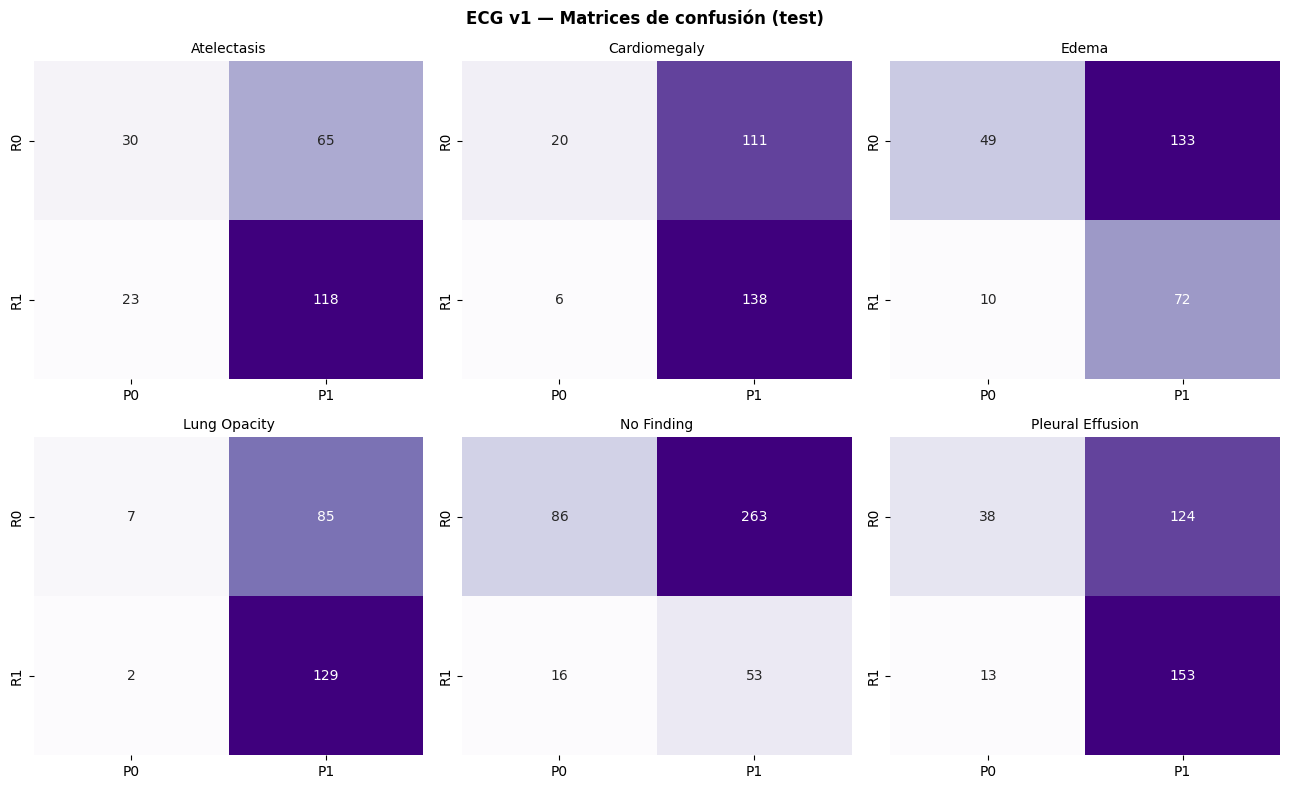

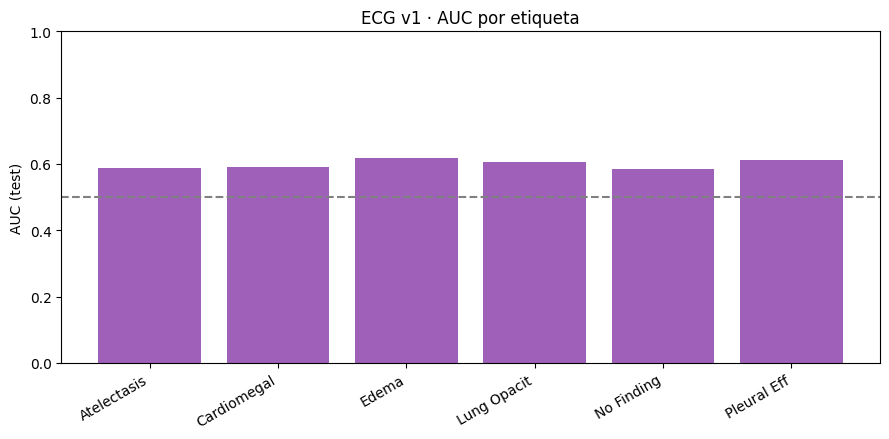

In [12]:
# CELDA 12 · MATRICES DE CONFUSIÓN + AUC por etiqueta
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle("ECG v1 — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    sns.heatmap(confusion_matrix(yt,yp,labels=[0,1]),annot=True,fmt="d",cmap="Purples",cbar=False,ax=ax,
                xticklabels=["P0","P1"],yticklabels=["R0","R1"]); ax.set_title(f"{l}",fontsize=10)
plt.tight_layout(); plt.savefig(FIG/"confusion_v1.png",dpi=150,bbox_inches="tight"); plt.show()
fig2,ax=plt.subplots(figsize=(9,4.5)); aucs=[M[l]["AUC"] for l in LABELS]
ax.bar(range(N_LABELS),[0 if np.isnan(a) else a for a in aucs],color=["#c0392b" if (np.isnan(a) or a<0.55) else "#8e44ad" for a in aucs],alpha=0.85)
ax.axhline(0.5,color="gray",ls="--"); ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS],rotation=30,ha="right")
ax.set_ylim(0,1); ax.set_ylabel("AUC (test)"); ax.set_title("ECG v1 · AUC por etiqueta")
plt.tight_layout(); plt.savefig(FIG/"auc_por_etiqueta_v1.png",dpi=150,bbox_inches="tight"); plt.show()

In [13]:
# CELDA 13 · EXPORTAR OOF/val/test PARA EL STACKING (hadm_id, ecg_<label>, ecg_<label>_cal)
def save_predictions(df, raw, cal, name):
    cols={"hadm_id":df["hadm_id"].to_numpy()}
    for j,l in enumerate(LABELS):
        key=l.replace(" ","_"); cols[f"ecg_{key}"]=raw[:,j]; cols[f"ecg_{key}_cal"]=cal[:,j]
    out=pd.DataFrame(cols); p=OUTPUT_DIR/f"ecg_pred_{name}.csv"; out.to_csv(p,index=False); print("   guardado",p.name)
save_predictions(df_train, oof_train, oof_cal, "oof_train")
save_predictions(df_val, val_pred_raw, val_pred, "val")
save_predictions(df_test, test_pred_raw, test_pred, "test")
print("OOF/val/test del ECG v1 exportados.")

   guardado ecg_pred_oof_train.csv
   guardado ecg_pred_val.csv
   guardado ecg_pred_test.csv
OOF/val/test del ECG v1 exportados.


---
## ✅ Resumen — ECG v1 (ligero)
ResNet1D **pequeña** (base 32, 1 bloque/etapa) sobre señal a **1000** muestras, K=3 con ensemble. Mantiene masking,
negativos derivados, `pos_weight`, calibración y **OOF sin fuga**. Es la base rápida; el **v2** (señal 1250, red mayor,
Optuna) y el **v3** (señal 2500, K=5) exprimen algo más el AUC a costa de horas.